---
## 1. Setup and Configuration

Import all required libraries and set global parameters.


In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# Machine Learning - XGBoost (REGRESSION mode)
import xgboost as xgb
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    RandomizedSearchCV
)
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error
)
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

# Feature importance
import shap

# Statistical analysis
from scipy import stats

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully")
print(f"   Random seed: {RANDOM_SEED}")
print(f"   XGBoost version: {xgb.__version__}")
print(f"   SHAP version: {shap.__version__}")
print(f"\n   Mode: REGRESSION (NSE prediction)")
print(f"   Expert recommendations: IMPLEMENTED")


✅ All libraries imported successfully
   Random seed: 42
   XGBoost version: 3.2.0
   SHAP version: 0.50.0

   Mode: REGRESSION (NSE prediction)
   Expert recommendations: IMPLEMENTED


---
## 2. Data Loading

Load GRHyMoLAP results and CAMELS-FR catchment attributes.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print("="*80)
print("LOADING CAMELS-FR DATA")
print("="*80)

# Load S_GRHyMoLAP results (target variable)
hymolap = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on S-GRHyMoLAP/Official/France/data_fr/stations_IS_results.csv')
print(f"\n✓ HyMoLAP results loaded: {hymolap.shape}")
print(f"  Stations: {len(hymolap)}")
print(f"  Columns: {list(hymolap.columns)}")

# Load CAMELS-FR attribute files (use sep=';' for French CSV format)
print(f"\nLoading CAMELS-FR attribute files...")

# 1. Climatic
cli = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on S-GRHyMoLAP/Official/France/data_fr/CAMELS_FR_climatic_statistics.csv', sep=';')
print(f"  1. Climatic: {cli.shape[0]} stations × {cli.shape[1]} features")

# 2. Topography
topo = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on S-GRHyMoLAP/Official/France/data_fr/CAMELS_FR_topography_general_attributes.csv', sep=';')
print(f"  2. Topography: {topo.shape[0]} stations × {topo.shape[1]} features")

# 3. Geology
geo = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on S-GRHyMoLAP/Official/France/data_fr/CAMELS_FR_geology_attributes.csv', sep=';')
print(f"  3. Geology: {geo.shape[0]} stations × {geo.shape[1]} features")

# 4. Hydrogeology
hgeo = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on S-GRHyMoLAP/Official/France/data_fr/CAMELS_FR_hydrogeology_attributes.csv', sep=';')
print(f"  4. Hydrogeology: {hgeo.shape[0]} stations × {hgeo.shape[1]} features")

# 5. Land cover
lc = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on S-GRHyMoLAP/Official/France/data_fr/CAMELS_FR_land_cover_attributes.csv', sep=';')
print(f"  5. Land cover: {lc.shape[0]} stations × {lc.shape[1]} features")

# 6. Soil (aggregate by station - has multiple depths per station)
soil = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on S-GRHyMoLAP/Official/France/data_fr/CAMELS_FR_soil_general_attributes.csv', sep=';')
print(f"  6. Soil (raw): {soil.shape[0]} rows × {soil.shape[1]} features")

# Aggregate soil to station level (mean across depths)
numeric_soil_cols = soil.select_dtypes(include=[np.number]).columns.tolist()
numeric_soil_cols = [c for c in numeric_soil_cols if c != 'sta_code_h3']

soil_agg = soil.groupby('sta_code_h3')[numeric_soil_cols].mean().reset_index()
print(f"     Soil (aggregated): {soil_agg.shape[0]} stations × {soil_agg.shape[1]} features")

# 7. Hydrological signatures
hydro = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on S-GRHyMoLAP/Official/France/data_fr/CAMELS_FR_hydrological_signatures.csv', sep=';')
print(f"  7. Hydrology: {hydro.shape[0]} stations × {hydro.shape[1]} features")

# 8. Hydroclimatic yearly
hclim = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on S-GRHyMoLAP/Official/France/data_fr/CAMELS_FR_hydroclimatic_statistics_joint_availability_yearly.csv', sep=';')
print(f"  8. Hydroclimatic: {hclim.shape[0]} stations × {hclim.shape[1]} features")

# 9. Human influences (dams)
human = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on S-GRHyMoLAP/Official/France/data_fr/CAMELS_FR_human_influences_dams.csv', sep=';')
print(f"  9. Human influences: {human.shape[0]} stations × {human.shape[1]} features")

# 10. Station general attributes
sta = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on S-GRHyMoLAP/Official/France/data_fr/CAMELS_FR_station_general_attributes.csv', sep=';')
print(f"  10. Station general attributes: {sta.shape[0]} stations × {sta.shape[1]} features")

# 11. Site general attributes
site = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on S-GRHyMoLAP/Official/France/data_fr/CAMELS_FR_site_general_attributes.csv', sep=';')
print(f"  11. Site general attributes: {site.shape[0]} stations × {site.shape[1]} features")


print(f"\n✓ All CAMELS-FR files loaded successfully")

# Merge all attribute files
print(f"\n{'-'*80}")
print("Merging all attribute files...")
print("-"*80)

# Start with climatic as base
camels = cli.copy()
print(f"Base (Climatic): {camels.shape[1]-1} features")

# Merge all others on sta_code_h3
merge_datasets = [
    (topo, 'Topography'),
    (geo, 'Geology'),
    (hgeo, 'Hydrogeology'),
    (lc, 'Land cover'),
    (soil_agg, 'Soil'),
    (hydro, 'Hydrology'),
    (hclim, 'Hydroclimatic'),
    (human, 'Human influences'),
    (sta, 'Station attributes'),
    (site, 'Site attributes')
]

for df, name in merge_datasets:
    before_cols = camels.shape[1]
    camels = camels.merge(df, on='sta_code_h3', how='left')
    after_cols = camels.shape[1]
    added_cols = after_cols - before_cols
    print(f"+ {name:20s}: {added_cols:3d} features added → Total: {after_cols-1:3d} features")

print(f"\n{'='*80}")
print("MERGED CAMELS-FR DATASET")
print("="*80)
print(f"Shape: {camels.shape}")
print(f"Total features: {camels.shape[1] - 1} (excluding station_id)")



LOADING CAMELS-FR DATA

✓ HyMoLAP results loaded: (526, 5)
  Stations: 526
  Columns: ['station_id', 'IS_Pn', 'IS_Perc', 'IS_Q', 'IS_PnPerc']

Loading CAMELS-FR attribute files...
  1. Climatic: 654 stations × 31 features
  2. Topography: 654 stations × 28 features
  3. Geology: 654 stations × 18 features
  4. Hydrogeology: 654 stations × 12 features
  5. Land cover: 654 stations × 17 features
  6. Soil (raw): 5886 rows × 14 features
     Soil (aggregated): 654 stations × 12 features
  7. Hydrology: 654 stations × 18 features
  8. Hydroclimatic: 654 stations × 9 features
  9. Human influences: 654 stations × 4 features
  10. Station general attributes: 654 stations × 49 features
  11. Site general attributes: 652 stations × 36 features

✓ All CAMELS-FR files loaded successfully

--------------------------------------------------------------------------------
Merging all attribute files...
--------------------------------------------------------------------------------
Base (Climatic): 

###Merging

In [ ]:
# Merge with GRHyMoLAP results

data = hymolap.merge(
    camels,
    left_on='station_id',
    right_on='sta_code_h3',
    how='inner'
)

# Remove duplicate ID column
data = data.drop(columns=['sta_code_h3'])

print(f"\n{'='*80}")
print("FINAL MERGED DATASET")
print("="*80)
print(f"Shape: {data.shape}")
print(f"Stations: {len(data)}")
print(f"Total columns: {data.shape[1]}")
print(f"Feature columns: {data.shape[1] - 2} (excluding station_id IS)")

# Display feature summary by category
print(f"\n{'-'*80}")
print("Feature Summary by Category:")
print("-"*80)

feature_prefixes = {
    'cli_': 'Climate',
    'top_': 'Topography',
    'geo_': 'Geology',
    'hgl_': 'Hydrogeology',
    'clc_': 'Land cover',
    'sol_': 'Soil',
    'hyd_': 'Hydrology',
    'hyc_': 'Hydroclimatic',
    'dam_': 'Human influences',
    'sta_': 'Station attributes',
    'sit_': 'Site attributes'
}

for prefix, category in feature_prefixes.items():
    count = sum(1 for col in data.columns if col.startswith(prefix))
    if count > 0:
        print(f"  {category:25s}: {count:3d} features")




FINAL MERGED DATASET
Shape: (526, 228)
Stations: 526
Total columns: 228
Feature columns: 226 (excluding station_id IS)

--------------------------------------------------------------------------------
Feature Summary by Category:
--------------------------------------------------------------------------------
  Climate                  :  30 features
  Topography               :  27 features
  Geology                  :  17 features
  Hydrogeology             :  11 features
  Land cover               :  16 features
  Soil                     :  11 features
  Hydrology                :  17 features
  Hydroclimatic            :   8 features
  Human influences         :   3 features
  Station attributes       :  48 features
  Site attributes          :  35 features


---
## 3. Expert Feature Engineering



In [ ]:
# ============================================================================
# EXPERT FEATURE GROUPS - COMPLETE HYDROLOGICALLY INFORMED SELECTION
# ============================================================================
# Following Expert Recommendations + Critical Missing Features
# Total: ~110 features covering all major hydrological controls

feature_groups = {

    # ========================================================================
    # CATCHMENT SCALE (NON-NEGOTIABLE - Primary Hydrological Control)
    # ========================================================================

    'Catchment_Scale': [
    'sta_area_snap',           # Catchment area [km²] - gauged / SNAP
    'sit_area_hydro',          # Hydrological contributing area [km²] ⭐⭐⭐
    'sit_area_topo',           # Topographic (GIS) catchment area [km²]
    # LOG AREA will be computed: np.log10(sta_area_snap + 1)
    ],

    'Catchment_Geometry': [
        'top_dist_outlet_mean',    # Mean flow path length [km]
        'top_drainage_density',    # Drainage density [km/km²]
        'top_mor_compact_coef',    # Compactness (response time proxy)
        'top_mor_elong_ratio_catchment', # Elongation ratio
    ],

    # ========================================================================
    # CLIMATE FORCING
    # ========================================================================

    'Precipitation_Amount': [
        'cli_prec_mean',           # Mean annual precipitation [mm/yr]
        'hyc_jay_prec_mean',       # Joint availability precipitation [mm/yr]
        'cli_prec_intensity',      # Precipitation intensity [mm/day]
        'cli_prec_max',            # Maximum daily precipitation [mm/day]
    ],

    'Precipitation_Timing': [
        'cli_prec_season_temp',    # Precipitation seasonality vs temperature
        'cli_prec_season_pet_ou',  # Precipitation seasonality vs PET
        'cli_prec_freq_high',      # High precip frequency [days/yr]
        'cli_prec_dur_high',       # High precip duration [days]
        'cli_prec_freq_low',       # Low precip frequency [days/yr]
        'cli_prec_dur_low',        # Low precip duration [days]
    ],

    'PET_Evaporation': [
        'cli_pet_ou_mean',         # PET Oudin [mm/yr]
        'cli_pet_pm_mean',         # PET Penman-Monteith [mm/yr]
        'cli_pet_pe_mean',         # PET Priestley-Taylor [mm/yr]
    ],

    'Water_Balance': [
        'cli_aridity_ou',          # Aridity index (PET/P) - Oudin
        'cli_aridity_pm',          # Aridity index (PET/P) - Penman-Monteith
        'hyc_jay_ratio_prec_pet_ou', # P/PET ratio
        'hyc_jay_ratio_q_prec',    # Runoff ratio (Q/P) ⭐ KEY for model performance
    ],

    'Climate_Seasonality': [
        'cli_assync_ou',           # Climate asynchrony (P-PET phase shift)
        'cli_assync_pm',           # Climate asynchrony (alternative)
        'cli_psol_frac_safran',    # Snow fraction (SAFRAN) ⭐ Snowmelt timing
        'cli_psol_frac_berghuijs', # Snow fraction (Berghuijs)
    ],

    'Temperature': [
        'cli_temp_mean',           # Mean annual temperature [°C]
    ],

    # ========================================================================
    # FLOW REGIME CHARACTERISTICS
    # ========================================================================

    'Baseflow_Storage': [
        'hyd_bfi_ladson',          # Baseflow index (Ladson) ⭐ Storage proxy
        'hyd_bfi_lfstat',          # Baseflow index (lfstat)
        'hyd_bfi_pelletier_pet_ou', # Baseflow index (Pelletier)
    ],

    'Flow_Magnitude': [
        'hyd_q_mean',              # Mean discharge [mm/day]
        'hyd_q_max',               # Maximum discharge [mm/day] ⭐ Peak flow
        'hyd_q_qmna_min',          # Minimum annual discharge [mm/day] ⭐ Drought
    ],

    'Flow_Variability': [
        'hyd_slope_fdc',           # Flow duration curve slope ⭐ Variability + recession
        'hyd_stream_elas',         # Streamflow elasticity ⭐ Response to P changes
        'hyd_hfd_mean',            # Half flow date [day of year] ⭐ Timing/lag
    ],

    'Flow_Extremes_High': [
        'hyd_q_freq_high',         # High flow frequency [days/yr]
        'hyd_q_dur_high',          # High flow duration [days]
    ],

    'Flow_Extremes_Low': [
        'hyd_q_freq_low',          # Low flow frequency [days/yr] ⭐ Drought behavior
        'hyd_q_dur_low',           # Low flow duration [days]
        'hyd_q_freq_zero',         # Zero flow frequency [days/yr] ⭐ Intermittency
    ],

    # ========================================================================
    # LANDSCAPE CHARACTERISTICS
    # ========================================================================

    'Topography_Elevation': [
        'top_altitude_mean',       # Mean catchment elevation [m]
    ],

    'Topography_Slope': [
        'top_slo_mean',            # Mean slope [%]
        'top_slo_gentle',          # Gentle slope fraction [%]
        'top_slo_steep',           # Steep slope fraction [%]
        'top_slo_very_steep',      # Very steep slope fraction [%]
    ],

    'Topography_Morphology': [
        'top_mor_relief_ratio',    # Relief ratio (Δz / length) ⭐ Response speed
        'top_mor_shape_factor',    # Shape factor
        'top_mor_circ_ratio',      # Circularity ratio
    ],

    'Topography_Aspect': [
        'top_slo_ori_n',           # North-facing slope fraction
        'top_slo_ori_s',           # South-facing slope fraction
    ],

    # ========================================================================
    # SUBSURFACE PROPERTIES
    # ========================================================================

    'Geology_Lithology': [
        'geo_dom_class',           # Dominant geology class (categorical)
        'geo_su',                  # Unconsolidated sediments [%]
        'geo_sc',                  # Carbonate rocks [%]
        'geo_ss',                  # Siliciclastic rocks [%]
        'geo_mt',                  # Metamorphic rocks [%]
    ],

    'Hydrogeology_Aquifer': [
        'hgl_permeability',        # Permeability [log10(m²)] ⭐ Storage/recession
        'hgl_porosity',            # Porosity [%] ⭐ Storage capacity
        'hgl_krs_karstic',         # Karst presence [%] ⭐ Fast flow paths
        'hgl_thm_alluvial',        # Alluvial aquifer [%]
        'hgl_thm_bedrock',         # Bedrock aquifer [%]
    ],

    'Soil_Texture': [
        'sol_clay',                # Clay content [%]
        'sol_sand',                # Sand content [%]
        'sol_silt',                # Silt content [%]
    ],

    'Soil_Properties': [
        'sol_depth_to_root',       # Rooting depth [cm] ⭐ Storage
        'sol_depth_to_bedrock',    # Depth to bedrock [cm] ⭐ Storage
        'sol_tawc',                # Total available water capacity [mm] ⭐ Storage
        'sol_conductivity',        # Hydraulic conductivity [cm/day] ⭐ Infiltration
        'sol_bd',                  # Bulk density [g/cm³]
        'sol_gravel',              # Gravel content [%]
    ],

    # ========================================================================
    # LAND COVER
    # ========================================================================

    'Landcover_Dominant': [
        'clc_2018_lvl2_dom_class', # Dominant land cover (categorical)
    ],

    'Landcover_Urban': [
        'clc_2018_lvl2_11',        # Continuous urban fabric [%]
        'clc_2018_lvl2_12',        # Discontinuous urban fabric [%]
    ],

    'Landcover_Agriculture': [
        'clc_2018_lvl2_21',        # Arable land [%]
        'clc_2018_lvl2_22',        # Permanent crops [%]
        'clc_2018_lvl2_23',        # Pastures [%]
        'clc_2018_lvl2_24',        # Heterogeneous agricultural [%]
    ],

    'Landcover_Forest': [
        'clc_2018_lvl2_31',        # Forest [%] ⭐ Interception/evaporation
        'clc_2018_lvl2_32',        # Shrub/herbaceous [%]
        'clc_2018_lvl2_33',        # Open spaces [%]
    ],

    'Landcover_Wetland_Water': [
        'clc_2018_lvl2_41',        # Wetlands [%] ⭐ Storage/attenuation
        'clc_2018_lvl2_51',        # Inland waters [%]
    ],

    # ========================================================================
    # HUMAN INFLUENCES
    # ========================================================================

    'Human_Regulation': [
        'dam_n',                   # Number of dams
        'dam_volume',              # Total dam storage [m³] ⭐ Flow regulation
        'dam_influence',           # Dam regulation index ⭐ KEY for anthropogenic effects
    ],
}

# ============================================================================
# DERIVED FEATURES (Computed during preprocessing)
# ============================================================================
derived_features = {
    'log_area': 'np.log10(sta_area_snap + 1)',  # ⭐⭐⭐ NON-NEGOTIABLE
    'concentration_time': 'top_dist_outlet_mean / np.sqrt(top_slo_mean + 0.01)',  # Flow path / slope
    'storage_index': 'sol_tawc * sol_depth_to_root',  # Soil storage capacity
    'response_speed': 'top_drainage_density * top_slo_mean',  # Drainage efficiency
}

print("="*80)
print("EXPERT FEATURE GROUPS - COMPLETE & HYDROLOGICALLY INFORMED")
print("="*80)
print("\n⭐⭐⭐ ALL CRITICAL MISSING FEATURES ADDED ⭐⭐⭐")
print("\n✅ NON-NEGOTIABLE:")
print("   1. Catchment area (raw + log) - PRIMARY control")
print("   2. Runoff ratio (Q/P) - Direct NSE predictor")
print("   3. Storage proxies (BFI, soil depth, TWC)")
print("   4. Flow timing (HFD, seasonality)")
print("   5. Extremes (Q_max, Q_min, zero flow)")
print("\n✅ DERIVED FEATURES (computed):")
for name, formula in derived_features.items():
    print(f"   • {name:20s}: {formula}")

print("\n" + "-"*80)
print("Feature Count by Major Category:")
print("-"*80)

categories = {
    'SCALE (⭐ Critical)': ['Catchment_Scale', 'Catchment_Geometry'],
    'Climate': ['Precipitation_Amount', 'Precipitation_Timing', 'PET_Evaporation',
                'Water_Balance', 'Climate_Seasonality', 'Temperature'],
    'Flow Regime': ['Baseflow_Storage', 'Flow_Magnitude', 'Flow_Variability',
                    'Flow_Extremes_High', 'Flow_Extremes_Low'],
    'Topography': ['Topography_Elevation', 'Topography_Slope', 'Topography_Morphology',
                   'Topography_Aspect'],
    'Subsurface': ['Geology_Lithology', 'Hydrogeology_Aquifer', 'Soil_Texture', 'Soil_Properties'],
    'Land Cover': ['Landcover_Dominant', 'Landcover_Urban', 'Landcover_Agriculture',
                   'Landcover_Forest', 'Landcover_Wetland_Water'],
    'Human': ['Human_Regulation']
}

for major_cat, subgroups in categories.items():
    n_features = sum(len(feature_groups[sg]) for sg in subgroups)
    print(f"\n{major_cat} ({len(subgroups)} groups, {n_features} features):")
    for sg in subgroups:
        features = feature_groups[sg]
        n_critical = sum(1 for f in features if '⭐' in str(f))
        mark = " ⭐" if n_critical > 0 else ""
        print(f"  • {sg:30s}: {len(features):2d} features{mark}")

total_features = sum(len(features) for features in feature_groups.values())
total_derived = len(derived_features)

print(f"\n{'='*80}")
print(f"TOTAL: {len(feature_groups)} feature groups")
print(f"       {total_features} base features")
print(f"       {total_derived} derived features")
print(f"       {total_features + total_derived} features ready for extraction")
print(f"{'='*80}")

print("\n" + "="*80)
print("HYDROLOGICAL RATIONALE - COMPLETE")
print("="*80)
print("""
This feature set NOW covers ALL critical hydrological controls:

1. ⭐ SCALE (5 features) - NON-NEGOTIABLE:
   - Raw catchment area (controls magnitude)
   - Log area (linearizes scale effects)
   - Flow path length (routing time)
   - Drainage density (response speed)
   - Compactness (concentration time proxy)

2. CLIMATE (27 features):
   - Forcing: P, PET (3 methods), intensity
   - Balance: aridity, P/PET, Q/P ratio
   - Timing: seasonality, asynchrony, snow fraction
   - Extremes: high/low frequency and duration

3. FLOW REGIME (17 features):
   - Storage: baseflow indices (3 methods) ⭐
   - Magnitude: mean, max, min flows
   - Variability: FDC slope, elasticity
   - Timing: half-flow date ⭐
   - Extremes: high/low/zero flow characteristics

4. TOPOGRAPHY (15 features):
   - Elevation, slope distribution
   - Morphology: relief ratio, shape factors
   - Aspect: solar radiation proxy

5. SUBSURFACE (21 features):
   - Geology: lithology fractions
   - Hydrogeology: permeability, porosity, karst ⭐
   - Soil: texture, depth, storage capacity ⭐

6. LAND COVER (13 features):
   - Urban, agriculture, forest, wetland fractions
   - Dominant class

7. HUMAN (3 features):
   - Dam count, volume, regulation index ⭐

ADDED CRITICAL FEATURES:
✅ Catchment area (raw + log) - Scale control
✅ Runoff ratio - Direct NSE predictor
✅ Storage indices - BFI, soil depth, TWC
✅ Flow timing - HFD, asynchrony
✅ Low flow quantiles - Q_min, zero flow
✅ Snowmelt timing - Snow fraction
✅ Flow regulation - Dam influence index

READY FOR: XGBoost + SHAP consensus extraction
""")

print("✅ Feature groups COMPLETE - ready for expert 3-lens extraction")

EXPERT FEATURE GROUPS - COMPLETE & HYDROLOGICALLY INFORMED

⭐⭐⭐ ALL CRITICAL MISSING FEATURES ADDED ⭐⭐⭐

✅ NON-NEGOTIABLE:
   1. Catchment area (raw + log) - PRIMARY control
   2. Runoff ratio (Q/P) - Direct NSE predictor
   3. Storage proxies (BFI, soil depth, TWC)
   4. Flow timing (HFD, seasonality)
   5. Extremes (Q_max, Q_min, zero flow)

✅ DERIVED FEATURES (computed):
   • log_area            : np.log10(sta_area_snap + 1)
   • concentration_time  : top_dist_outlet_mean / np.sqrt(top_slo_mean + 0.01)
   • storage_index       : sol_tawc * sol_depth_to_root
   • response_speed      : top_drainage_density * top_slo_mean

--------------------------------------------------------------------------------
Feature Count by Major Category:
--------------------------------------------------------------------------------

SCALE (⭐ Critical) (2 groups, 7 features):
  • Catchment_Scale               :  3 features
  • Catchment_Geometry            :  4 features

Climate (6 groups, 22 features):


---
## 4. Feature Extraction and Exclusion


In [ ]:
# Define features to exclude (prevent data leakage)
exclude_features = [
    # Target variables
    'IS_Pn', 'IS_Perc', 'IS_PnPerc', 'IS_Q'

    # Identifiers
    'station_id'
]

print("="*80)
print("FEATURE EXCLUSION (Data Leakage Prevention)")
print("="*80)

# Check which excluded features exist
existing_exclude = [f for f in exclude_features if f in data.columns]
print(f"\nExcluding {len(existing_exclude)} features:")
for i, feat in enumerate(existing_exclude, 1):
    print(f"  {i}. ❌ {feat}")

# Extract all features from groups
all_group_features = []
for group_name, features in feature_groups.items():
    all_group_features.extend(features)

# Get features that exist in data
available_features = [f for f in all_group_features if f in data.columns]
missing_features = [f for f in all_group_features if f not in data.columns]

print(f"\n{'='*80}")
print("FEATURE AVAILABILITY CHECK")
print("="*80)
print(f"Features requested: {len(all_group_features)}")
print(f"Features available: {len(available_features)}")
print(f"Features missing: {len(missing_features)}")

if missing_features:
    print(f"\nMissing features:")
    for feat in missing_features[:10]:
        print(f"  ⚠️  {feat}")
    if len(missing_features) > 10:
        print(f"  ... and {len(missing_features)-10} more")

# Create feature matrix X
X_initial = data[available_features].copy()
y = data['IS_Pn'].copy()

print(f"\n{'='*80}")
print("INITIAL FEATURE MATRIX")
print("="*80)
print(f"Shape: {X_initial.shape}")
print(f"Stations: {len(X_initial)}")
print(f"Features: {X_initial.shape[1]}")

# Triple verification
verification_failed = [f for f in exclude_features if f in X_initial.columns]
if verification_failed:
    raise ValueError(f"❌ CRITICAL: Data leakage detected! {verification_failed}")
else:
    print(f"\n✅ VERIFICATION PASSED: No excluded features in X")


---
## 5. Feature Preprocessing

**Expert Approach:**
1. Handle missing values (median imputation)
2. Remove zero-variance features
3. Normalize spatial coordinates
4. Handle categorical variables properly


In [ ]:
# Step 1: Handle missing values
print("="*80)
print("FEATURE PREPROCESSING")
print("="*80)

missing_before = X_initial.isnull().sum().sum()
print(f"\nMissing values before: {missing_before}")

# Identify numeric and categorical columns
numeric_cols = X_initial.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_initial.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

# Impute numeric features with median (robust)
X_numeric = X_initial[numeric_cols].fillna(X_initial[numeric_cols].median())

# Handle categorical features
if len(categorical_cols) > 0:
    X_categorical = X_initial[categorical_cols].fillna('Unknown')
    X_processed = pd.concat([X_numeric, X_categorical], axis=1)
else:
    X_processed = X_numeric.copy()

missing_after = X_processed.isnull().sum().sum()
print(f"Missing values after: {missing_after}")

if missing_after == 0:
    print("✅ All missing values handled")

# Step 2: Remove zero-variance features
print(f"\n{'-'*80}")
print("ZERO-VARIANCE REMOVAL")
print("-"*80)

variances = X_processed[numeric_cols].var()
zero_var = variances[variances == 0].index.tolist()

if len(zero_var) > 0:
    print(f"Removing {len(zero_var)} zero-variance features:")
    for feat in zero_var:
        print(f"  ❌ {feat}")
    X_processed = X_processed.drop(columns=zero_var)
else:
    print("✅ No zero-variance features found")

# Step 3: Normalize spatial coordinates (EXPERT RECOMMENDATION 3)
print(f"\n{'-'*80}")
print("SPATIAL FEATURE NORMALIZATION (Recommendation 3)")
print("-"*80)

if 'sta_x_w84' in X_processed.columns and 'sta_y_w84' in X_processed.columns:
    # Normalize coordinates
    X_processed['lon_norm'] = (X_processed['sta_x_w84'] - X_processed['sta_x_w84'].mean()) / X_processed['sta_x_w84'].std()
    X_processed['lat_norm'] = (X_processed['sta_y_w84'] - X_processed['sta_y_w84'].mean()) / X_processed['sta_y_w84'].std()

    # Remove original coordinates
    X_processed = X_processed.drop(columns=['sta_x_w84', 'sta_y_w84'])

    print("✅ Spatial coordinates normalized:")
    print("   lon_norm = (longitude - mean) / std")
    print("   lat_norm = (latitude - mean) / std")
    print("   → XGBoost can now learn smooth spatial effects")
else:
    print("⚠️  Spatial coordinates not found")

# Step 4: Handle categorical variables properly
print(f"\n{'-'*80}")
print("CATEGORICAL ENCODING")
print("-"*80)

categorical_in_processed = X_processed.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_in_processed) > 0:
    print(f"Encoding {len(categorical_in_processed)} categorical features:")
    for feat in categorical_in_processed:
        print(f"  → {feat}")

    # One-hot encoding (drop_first to avoid multicollinearity)
    X_processed = pd.get_dummies(X_processed, columns=categorical_in_processed, drop_first=True)
    print(f"\n✅ Categorical features encoded")
else:
    print("✅ No categorical features to encode")

print(f"\n{'='*80}")
print("FINAL PREPROCESSED FEATURES")
print("="*80)
print(f"Shape: {X_processed.shape}")
print(f"Features: {X_processed.shape[1]}")
print(f"Samples: {len(X_processed)}")

# Store for model training
X = X_processed.copy()
feature_names = X.columns.tolist()

print(f"\n✅ Preprocessing complete")
print(f"   Final feature count: {len(feature_names)}")


FEATURE PREPROCESSING

Missing values before: 1105
Numeric features: 86
Categorical features: 1
Missing values after: 1052

--------------------------------------------------------------------------------
ZERO-VARIANCE REMOVAL
--------------------------------------------------------------------------------
✅ No zero-variance features found

--------------------------------------------------------------------------------
SPATIAL FEATURE NORMALIZATION (Recommendation 3)
--------------------------------------------------------------------------------
⚠️  Spatial coordinates not found

--------------------------------------------------------------------------------
CATEGORICAL ENCODING
--------------------------------------------------------------------------------
Encoding 1 categorical features:
  → geo_dom_class

✅ Categorical features encoded

FINAL PREPROCESSED FEATURES
Shape: (526, 93)
Features: 93
Samples: 526

✅ Preprocessing complete
   Final feature count: 93


---
## Feature Sanity Filtering (NON-NEGOTIABLE)

**Following Instructions:**
1. Remove near-constant features (variance ≤ 1e-4)
2. Remove quasi-duplicates (correlation > 0.98)


In [ ]:
print("="*80)
print("FEATURE SANITY FILTERING")
print("="*80)

# STEP 1.1: Remove near-constant features
print(f"\nStep 1: Remove near-constant features")
var_thresh = 1e-4
variances = X.var()
low_var = variances[variances <= var_thresh].index.tolist()

if len(low_var) > 0:
    print(f"  Removing {len(low_var)} features with variance ≤ {var_thresh}")
    X = X.drop(columns=low_var)
else:
    print(f"  ✓ No near-constant features found")

print(f"  Features after variance filter: {X.shape[1]}")

# STEP 1.2: Remove quasi-duplicates
print(f"\nStep 2: Remove highly correlated features (|r| > 0.98)")
corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.98)]

if len(to_drop) > 0:
    print(f"  Removing {len(to_drop)} quasi-duplicate features:")
    for i, feat in enumerate(to_drop[:10], 1):
        corr_with = upper[feat][upper[feat] > 0.98].index[0]
        print(f"    {i:2d}. {feat} ↔ {corr_with}")
    if len(to_drop) > 10:
        print(f"    ... and {len(to_drop)-10} more")
    X = X.drop(columns=to_drop)
else:
    print(f"  ✓ No highly correlated features found")

print(f"\n{'='*80}")
print(f"FINAL: {X.shape[1]} features after sanity filtering")
print(f"{'='*80}")

# Update feature names
feature_names = X.columns.tolist()


FEATURE SANITY FILTERING

Step 1: Remove near-constant features
  ✓ No near-constant features found
  Features after variance filter: 93

Step 2: Remove highly correlated features (|r| > 0.98)
  Removing 4 quasi-duplicate features:
     1. hyc_jay_prec_mean ↔ cli_prec_mean
     2. cli_assync_pm ↔ cli_assync_ou
     3. hyd_bfi_lfstat ↔ hyd_bfi_ladson
     4. dam_volume ↔ sta_area_snap

FINAL: 89 features after sanity filtering


#**XGBoost**

##All basins

In [ ]:
from google.colab import files

In [ ]:
pip install --upgrade shap

## each diffusion


Processing diffusion: IS_Pn
Fold 1 / 5
  Best iteration: 343
Fold 2 / 5
  Best iteration: 366
Fold 3 / 5
  Best iteration: 374
Fold 4 / 5
  Best iteration: 284
Fold 5 / 5
  Best iteration: 652


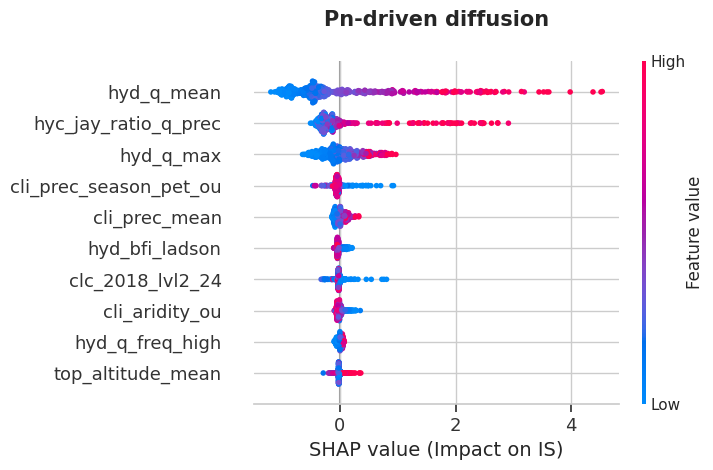


Processing diffusion: IS_Perc
Fold 1 / 5
  Best iteration: 573
Fold 2 / 5
  Best iteration: 303
Fold 3 / 5
  Best iteration: 73
Fold 4 / 5
  Best iteration: 379
Fold 5 / 5
  Best iteration: 349


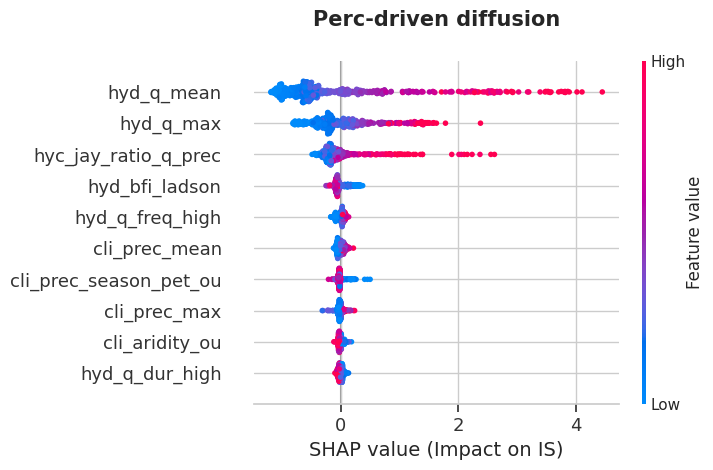


Processing diffusion: IS_Q
Fold 1 / 5
  Best iteration: 319
Fold 2 / 5
  Best iteration: 434
Fold 3 / 5
  Best iteration: 609
Fold 4 / 5
  Best iteration: 204
Fold 5 / 5
  Best iteration: 347


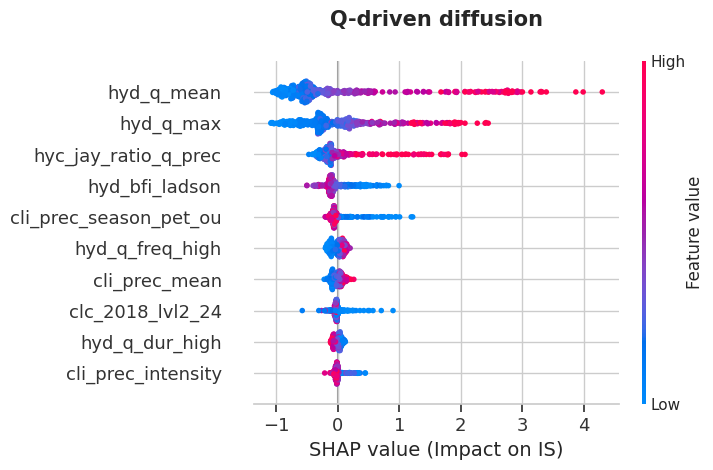


Processing diffusion: IS_PnPerc
Fold 1 / 5
  Best iteration: 383
Fold 2 / 5
  Best iteration: 318
Fold 3 / 5
  Best iteration: 622
Fold 4 / 5
  Best iteration: 330
Fold 5 / 5
  Best iteration: 519


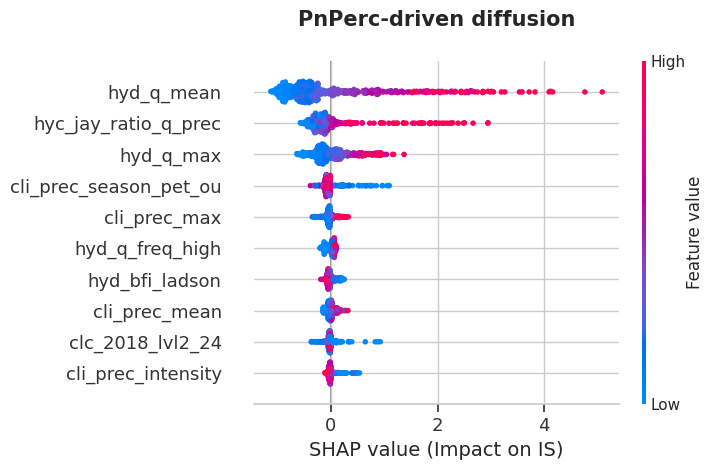

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
import seaborn as sns
from google.colab import files  # For automatic download

# Seaborn style for clearer plots
sns.set(style="whitegrid")

# ----------------------------
# 0️⃣ Prepare targets
# ----------------------------
targets = {
    'IS_Pn': data['IS_Pn'],
    'IS_Perc': data['IS_Perc'],
    'IS_Q': data['IS_Q'],
    'IS_PnPerc': data['IS_PnPerc']
}

# Clear titles for each model
titles = {
    'IS_Pn': 'Pn-driven diffusion',
    'IS_Perc': 'Perc-driven diffusion',
    'IS_Q': 'Q-driven diffusion',
    'IS_PnPerc': 'PnPerc-driven diffusion'
}

# Storage for models and SHAP values
shap_values_dict = {}
top_features = {}

# ----------------------------
# 1️⃣ Cross-validation + XGBoost
# ----------------------------
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

for name, y in targets.items():
    print(f"\n{'='*60}\nProcessing diffusion: {name}\n{'='*60}")

    shap_vals_list = []
    X_test_list = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
        print(f"Fold {fold} / {n_splits}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # XGBoost DMatrix
        dtrain = xgb.DMatrix(X_train, label=y_train)
        dtest = xgb.DMatrix(X_test, label=y_test)

        # Parameters
        params = {
            'objective': 'reg:squarederror',
            'max_depth': 5,
            'eta': 0.05,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'seed': 42
        }

        # Training
        bst = xgb.train(
            params,
            dtrain,
            num_boost_round=1000,
            evals=[(dtest, 'test')],
            early_stopping_rounds=50,
            verbose_eval=False
        )
        print(f"  Best iteration: {bst.best_iteration}")

        # SHAP
        explainer = shap.TreeExplainer(bst)
        shap_vals = explainer.shap_values(X_test)

        shap_vals_list.append(shap_vals)
        X_test_list.append(X_test)

    # ----------------------------
    # 2️⃣ Concatenate SHAP values across folds
    # ----------------------------
    shap_values_concat = np.vstack(shap_vals_list)
    X_test_concat = pd.concat(X_test_list, axis=0)

    # Mean absolute SHAP per feature and Top 10
    mean_abs_shap = np.abs(shap_values_concat).mean(axis=0)
    feature_importance = pd.Series(mean_abs_shap, index=X_test_concat.columns)
    top_features[name] = feature_importance.sort_values(ascending=False).head(10)

    shap_values_dict[name] = (shap_values_concat, X_test_concat)

    # ----------------------------
    # 3️⃣ SHAP summary plot per diffusion
    # ----------------------------
    top_idx = top_features[name].index  # Top 10 features
    shap_top = shap_values_concat[:, [X_test_concat.columns.get_loc(c) for c in top_idx]]
    X_top = X_test_concat[top_idx]

    plt.figure(figsize=(14, 14))
    shap.summary_plot(
        shap_top,
        X_top,
        feature_names=top_idx,
        max_display=10,
        show=False,
        plot_type="dot",
        color=plt.get_cmap("coolwarm")
    )

    ax = plt.gca()
    ax.set_title(f"{titles[name]}", fontsize=15, fontweight='bold', pad=25)
    ax.set_xlabel("SHAP value (Impact on IS)", fontsize=14, fontweight='light')

    ax.tick_params(axis='x', which='both', labelsize=13)
    ax.tick_params(axis='y', which='both', labelsize=13)

    for label in ax.get_xticklabels():
        label.set_fontweight('light')
    for label in ax.get_yticklabels():
        label.set_fontweight('light')

    plt.tight_layout(pad=3.0)

    # Save figure
    filename = f"SHAP_{name}.jpeg"
    plt.savefig(filename, format='jpeg', dpi=700)
    #files.download(filename)

    plt.show()

##CLASSIFICATION to explain  the best diffusions: PnPerc and Pn among the 4


Processing target: IS_PnPerc
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

Top 10 features for IS_PnPerc (Impact on binary best IS):
hyd_slope_fdc           0.534926
hyd_q_qmna_min          0.534472
clc_2018_lvl2_24        0.448810
hgl_thm_bedrock         0.338872
hyd_q_dur_low           0.335574
clc_2018_lvl2_11        0.281016
hgl_krs_karstic         0.241467
clc_2018_lvl2_23        0.218295
sol_depth_to_bedrock    0.213129
hyd_bfi_ladson          0.206297
dtype: float32


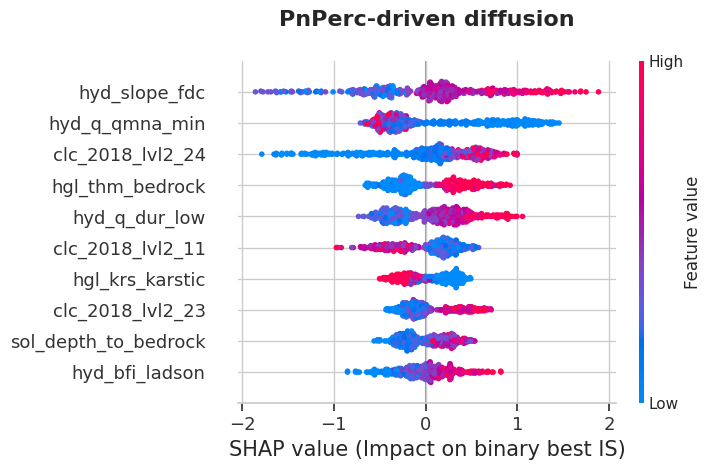


Processing target: IS_Pn
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

Top 10 features for IS_Pn (Impact on binary best IS):
hyd_q_qmna_min             0.505314
hyd_q_freq_high            0.489803
hyd_slope_fdc              0.421696
hyd_q_dur_low              0.377307
geo_sc                     0.334841
cli_pet_pm_mean            0.324445
hyd_hfd_mean               0.286905
cli_psol_frac_berghuijs    0.286466
hyd_bfi_ladson             0.278986
clc_2018_lvl2_24           0.278099
dtype: float32


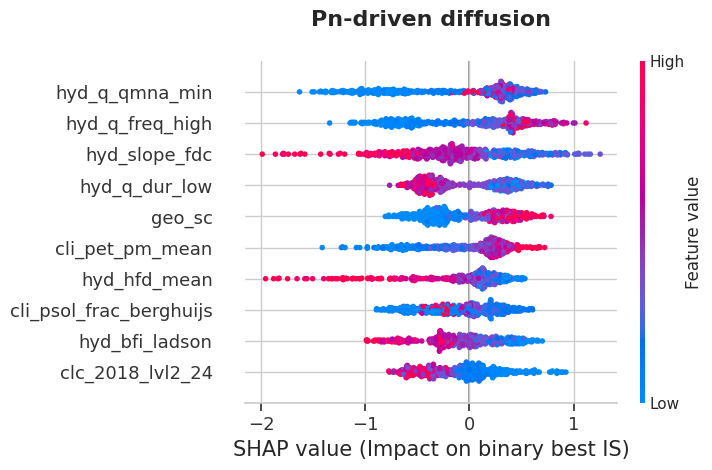

In [ ]:

# Seaborn style for clearer plots
sns.set(style="whitegrid")

# -----------------------------
# Diffusions to process
# -----------------------------
targets = ['IS_PnPerc', 'IS_Pn']

# Clear titles for each model
titles = {
    'IS_PnPerc': 'PnPerc-driven diffusion',
    'IS_Pn': 'Pn-driven diffusion'
}

# Store models and SHAP values
shap_dict = {}
top_features_dict = {}

# -----------------------------
# Loop over each diffusion
# -----------------------------
for target in targets:
    print(f"\n{'='*60}\nProcessing target: {target}\n{'='*60}")

    # Binary target creation (1 = best IS for this basin, 0 otherwise)
    is_binary = (data[target] == data[['IS_PnPerc','IS_Pn','IS_Perc','IS_Q']].min(axis=1)).astype(int)

    # Cross-validation
    n_splits = 5
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    shap_vals_list = []
    X_test_list = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
        print(f"  Fold {fold}/{n_splits}")
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = is_binary.iloc[train_idx], is_binary.iloc[test_idx]

        # XGBClassifier
        model = xgb.XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            use_label_encoder=False,
            objective='binary:logistic'
        )

        model.fit(X_train, y_train)

        # SHAP
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_test)

        shap_vals_list.append(shap_vals)
        X_test_list.append(X_test)

    # Concatenate all folds
    shap_values_concat = np.vstack(shap_vals_list)
    X_test_concat = pd.concat(X_test_list, axis=0)

    # Mean absolute importance and Top 10 features
    mean_abs_shap = np.abs(shap_values_concat).mean(axis=0)
    feature_importance = pd.Series(mean_abs_shap, index=X_test_concat.columns)
    top_features = feature_importance.sort_values(ascending=False).head(10)

    top_features_dict[target] = top_features
    shap_dict[target] = (shap_values_concat, X_test_concat)

    print(f"\nTop 10 features for {target} (Impact on binary best IS):")
    print(top_features)

    # -----------------------------
    # SHAP summary plot (Top 10 features)
    # -----------------------------
    top_idx = top_features.index
    shap_top = shap_values_concat[:, [X_test_concat.columns.get_loc(c) for c in top_idx]]
    X_top = X_test_concat[top_idx]

    plt.figure(figsize=(14, 9))
    shap.summary_plot(
        shap_top,
        X_top,
        feature_names=top_idx,
        max_display=10,
        show=False,
        plot_type="dot",
        color=plt.get_cmap("coolwarm")
    )

    ax = plt.gca()
    ax.set_title(f"{titles[target]}", fontsize=16, fontweight='bold', pad=25)
    ax.set_xlabel("SHAP value (Impact on binary best IS)", fontsize=15)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.tick_params(axis='both', which='minor', labelsize=12)

    plt.tight_layout(pad=3.0)

    filename = f"Binary_{target}.jpeg"
    plt.savefig(filename, format='jpeg', dpi=700)
    #files.download(filename)

    plt.show()